In [1]:
import torch, os
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), 'GB')


for root, dirs, files in os.walk('/kaggle/input'):
    for f in files[:5]:   
        print(os.path.join(root, f))
    if files: print(f'  ... ({len(files)} files total in {root})')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/images/22_46.tif
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/images/13_43.tif
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/images/23_60.tif
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/images/26_60.tif
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/images/44_42.tif
  ... (5635 files total in /kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/images)
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/masks/22_46.tif
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/masks/13_43.tif
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/masks/23_60.tif
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/masks/26_60.tif
/kaggle/input/datasets/anushkapriya28/seg-data/data/us_nerve/masks/44_42.tif
  ... (5635 files total in /kaggle/input/datasets/anushkap

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'albumentations', '-q'], check=True)

import os, random, time, zipfile, warnings
from pathlib import Path
from typing import List

import numpy as np
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.modules.utils import _pair
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import GradScaler, autocast

warnings.filterwarnings('ignore')
print('All imports OK')

All imports OK


In [3]:
DATA_BASE   = '/kaggle/input/datasets/anushkapriya28/seg-data/data'
OUTPUT_DIR  = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IDRID_IMG_DIR = os.path.join(DATA_BASE, 'Idrid',    'images')
IDRID_MSK_DIR = os.path.join(DATA_BASE, 'Idrid',    'masks')
US_IMG_DIR    = os.path.join(DATA_BASE, 'us_nerve', 'images')
US_MSK_DIR    = os.path.join(DATA_BASE, 'us_nerve', 'masks')

print(f'IDRiD images : {len(os.listdir(IDRID_IMG_DIR))}')
print(f'IDRiD masks  : {len(os.listdir(IDRID_MSK_DIR))}')
print(f'US images    : {len(os.listdir(US_IMG_DIR))}')
print(f'US masks     : {len(os.listdir(US_MSK_DIR))}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

IDRiD images : 100
IDRiD masks  : 100
US images    : 5635
US masks     : 5635
Device: cuda


In [4]:
#utils.py
def generate_series(start_num, end_num):
    series, current_value, increment, upper_limit = [], start_num, 2, 10
    while current_value <= end_num:
        while current_value <= upper_limit and current_value <= end_num:
            series.append(current_value)
            current_value += increment
        increment += 2
        upper_limit += 10
    return series

def divide_list_into_n_sublists(lst, n):
    avg, sublists, last = len(lst) / float(n), [], 0.0
    while last < len(lst):
        sublists.append(lst[int(last):int(last + avg)])
        last += avg
    return sublists

def select_n_elements_with_repeats_and_fallback(series, n, mode=None):
    less_than_10    = [x for x in series if x < 10]
    greater_equal_10 = [x for x in series if x >= 10]
    half_n = n // 2
    selected_less = []
    while len(selected_less) < half_n:
        selected_less.extend(less_than_10)
    selected_less = selected_less[:half_n]
    remaining = n - len(selected_less)
    if len(greater_equal_10) >= remaining:
        subgroups = divide_list_into_n_sublists(greater_equal_10, remaining)
        selected_greater = []
        for g in subgroups:
            if g:
                selected_greater.append(np.max(g) if mode == 'max' else int(np.median(g)))
    else:
        selected_greater = greater_equal_10[:]
        while len(selected_greater) < remaining:
            selected_greater.extend(less_than_10)
        selected_greater = selected_greater[:remaining]
    return selected_less + selected_greater

In [5]:
# module.py
SeparableConv2d = nn.Conv2d

class DecomConv2D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, conv_type='conv',
                 stride=1, padding='same', dilation=1, bias=True):
        super().__init__()
        conv_layers = {'conv': nn.Conv2d, 'sep': SeparableConv2d, 'dwconv': nn.Conv2d}
        if conv_type not in conv_layers:
            raise ValueError(f'Unsupported conv type: {conv_type}')
        ConvLayer = conv_layers[conv_type]
        pv = padding if padding == 'same' else (padding, 0)
        ph = padding if padding == 'same' else (0, padding)
        if conv_type == 'dwconv':
            self.vertical_conv   = ConvLayer(in_channels, in_channels,   (kernel_size, 1), stride=stride, padding=pv, bias=bias, groups=in_channels)
            self.horizontal_conv = ConvLayer(in_channels, in_channels,   (1, kernel_size), stride=stride, padding=ph, bias=bias, groups=in_channels)
        else:
            self.vertical_conv   = ConvLayer(in_channels, out_channels,  (kernel_size, 1), stride=stride, padding=pv, dilation=dilation, bias=bias)
            self.horizontal_conv = ConvLayer(in_channels, out_channels,  (1, kernel_size), stride=stride, padding=ph, dilation=dilation, bias=bias)

    def forward(self, x):
        return self.vertical_conv(x) * self.horizontal_conv(x)


class MKConv2D(nn.Module):
    def __init__(self, in_channels, out_channels, mode=None, decom_conv='conv',
                 stride=1, padding='same', bias=True):
        super().__init__()
        self.in_channels = in_channels; self.out_channels = out_channels
        self.mode = mode; self.decom_conv = decom_conv
        self.stride = stride; self.padding = padding; self.bias = bias
        self.convs = nn.ModuleList(); self.kernel_sizes = []

    def _initialize_convs(self, input_size):
        max_ks = (min(input_size) // 3) * 2
        possible = generate_series(3, max_ks)
        self.kernel_sizes = select_n_elements_with_repeats_and_fallback(possible, self.out_channels, mode=self.mode)
        self.convs = nn.ModuleList([self._get_conv_layer(i) for i in range(self.out_channels)])

    def _get_conv_layer(self, i):
        ks = self.kernel_sizes[i]
        if ks > 10:
            return DecomConv2D(self.in_channels, 1, kernel_size=ks, conv_type=self.decom_conv,
                               stride=self.stride, padding=self.padding, bias=self.bias)
        return nn.Conv2d(self.in_channels, 1, kernel_size=ks, stride=self.stride,
                         padding=self.padding, bias=self.bias)

    def forward(self, x):
        if len(self.convs) == 0:
            self._initialize_convs(x.shape[2:])
        self.convs = self.convs.to(x.device)
        return torch.cat([c(x) for c in self.convs], dim=1)


class CausalConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1,
                 padding=None, dilation=1, groups=1, bias=True):
        kernel_size = _pair(kernel_size); stride = _pair(stride); dilation = _pair(dilation)
        if padding is None:
            padding = [int((kernel_size[i]-1)*dilation[i]) for i in range(len(kernel_size))]
        else:
            padding = padding * 2
        self.left_padding = _pair(padding)
        super().__init__(in_channels, out_channels, kernel_size, stride=stride,
                         padding=0, dilation=dilation, groups=groups, bias=bias)

    def forward(self, x):
        x = F.pad(x, (self.left_padding[1], 0, self.left_padding[0], 0))
        return super().forward(x)

In [6]:
# blocksv2.py
def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

def get_conv_layer(in_c, out_c, k_sz=3, padding='same', conv_mode='Conv2d'):
    if conv_mode == 'Conv2d':
        return nn.Conv2d(in_c, out_c, kernel_size=k_sz, padding=padding)
    elif conv_mode == 'MKConv2D':
        return MKConv2D(in_c, out_c, mode='max', decom_conv='conv', padding=padding)
    elif conv_mode == 'DecomConv2D':
        return DecomConv2D(in_c, out_c, kernel_size=k_sz, padding=padding)
    elif conv_mode == 'SeparableConv2d':
        return SeparableConv2d(in_c, out_c, kernel_size=k_sz,
                               padding=padding if isinstance(padding, int) else 1)
    else:
        raise ValueError(f'Unsupported conv_mode: {conv_mode}')


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, shortcut=False, pool=True, conv_mode='Conv2d'):
        super().__init__()
        self.shortcut = nn.Sequential(conv1x1(in_c, out_c), nn.BatchNorm2d(out_c)) if shortcut else False
        self.pool = nn.MaxPool2d(kernel_size=2) if pool else False
        block = [
            get_conv_layer(in_c, out_c, k_sz=k_sz, padding='same', conv_mode=conv_mode),
            nn.ReLU(), nn.BatchNorm2d(out_c),
            get_conv_layer(out_c, out_c, k_sz=k_sz, padding='same', conv_mode=conv_mode),
            nn.ReLU(), nn.BatchNorm2d(out_c),
        ]
        self.block = nn.Sequential(*block)

    def forward(self, x):
        if self.pool: x = self.pool(x)
        out = self.block(x)
        if self.shortcut: out = out + self.shortcut(x)
        return out


class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, conv_mode='Conv2d'):
        super().__init__()
        self.mish   = nn.GELU()
        self.conv1  = nn.Conv2d(in_c, out_c // 4, 1)
        self.conv2  = get_conv_layer(out_c//4, out_c//4, k_sz=k_sz, padding='same', conv_mode=conv_mode)
        self.dropout= nn.Dropout(0.2)
        self.bn3    = nn.BatchNorm2d(out_c // 4)
        self.conv5  = nn.Conv2d(out_c // 4, out_c, 1, 1, bias=False)
        self.conv6  = nn.Conv2d(in_c, out_c, 1, 1, padding='same', bias=False)

    def forward(self, x):
        out = self.mish(self.conv1(x))
        out = self.bn3(self.dropout(self.mish(self.conv2(out))))
        return self.conv5(out) + self.conv6(x)


class Trunk(nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, residual=True, causal=True, conv_mode='Conv2d'):
        super().__init__()
        if residual:
            self.conv = nn.Sequential(ResBlock(in_c, out_c, k_sz, conv_mode),
                                      ResBlock(out_c, out_c, k_sz, conv_mode))
        elif causal:
            self.conv = nn.Sequential(CausalConv2d(in_c, out_c, k_sz), nn.BatchNorm2d(out_c), nn.ReLU(),
                                      CausalConv2d(out_c, out_c, k_sz), nn.BatchNorm2d(out_c), nn.ReLU())
        else:
            self.conv = nn.Sequential(get_conv_layer(in_c, out_c, k_sz, 'same', conv_mode),
                                      nn.BatchNorm2d(out_c), nn.ReLU(),
                                      get_conv_layer(out_c, out_c, k_sz, 'same', conv_mode),
                                      nn.BatchNorm2d(out_c), nn.ReLU())

    def forward(self, x): return self.conv(x)


class AttConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, shortcut=False, pool='pool',
                 attention=False, residual=True, causal=True, conv_mode='Conv2d'):
        super().__init__()
        self.shortcut = nn.Sequential(conv1x1(in_c, out_c), nn.BatchNorm2d(out_c)) if shortcut else False
        if pool == 'pool':   self.pool = nn.MaxPool2d(kernel_size=2)
        elif pool == 'conv': self.pool = nn.Conv2d(in_c, in_c, kernel_size=2, stride=2)
        else:                self.pool = False
        self.conv = Trunk(in_c, out_c, k_sz, residual, causal, conv_mode)
        if attention:
            self.mpool1 = nn.MaxPool2d(2, 2, 0)
            self.softmax1_blocks = nn.Conv2d(in_c, out_c, k_sz, padding='same', dilation=2)
            self.skip1_connection_residual_block = nn.Conv2d(out_c, out_c, k_sz, padding='same')
            self.mpool2 = nn.MaxPool2d(2, 2, 0)
            self.softmax2_blocks = nn.Conv2d(out_c, out_c, k_sz, padding='same', dilation=4)
            self.skip2_connection_residual_block = nn.Conv2d(out_c, out_c, k_sz, padding='same')
            self.mpool3 = nn.MaxPool2d(3, 2, 1)
            self.softmax3_blocks = nn.Sequential(
                nn.Conv2d(out_c, out_c, k_sz, padding='same', dilation=8),
                nn.Conv2d(out_c, out_c, k_sz, padding='same', dilation=8))
            self.interpolation3 = nn.Upsample(scale_factor=2)
            self.softmax4_blocks = nn.Conv2d(out_c, out_c, k_sz, padding='same', dilation=4)
            self.interpolation2 = nn.Upsample(scale_factor=2)
            self.softmax5_blocks = nn.Conv2d(out_c, out_c, k_sz, padding='same', dilation=2)
            self.interpolation1 = nn.Upsample(scale_factor=2)
            self.softmax6_blocks = nn.Sequential(
                nn.BatchNorm2d(out_c), nn.ReLU(True),
                nn.Conv2d(out_c, out_c, 1, bias=False),
                nn.BatchNorm2d(out_c), nn.ReLU(True),
                nn.Conv2d(out_c, out_c, 1, bias=False), nn.Sigmoid())
            self.last_blocks = nn.Conv2d(out_c, out_c, k_sz, padding='same')

    def forward(self, x, attention=False):
        if self.pool: x = self.pool(x)
        out_trunk = self.conv(x)
        if attention:
            s1 = self.softmax1_blocks(self.mpool1(x))
            sk1 = self.skip1_connection_residual_block(s1)
            s2 = self.softmax2_blocks(self.mpool2(s1))
            sk2 = self.skip2_connection_residual_block(s2)
            s3 = self.softmax3_blocks(self.mpool3(s2))
            out = self.softmax4_blocks(torch.add(self.interpolation3(s3), sk2))
            out = self.softmax5_blocks(torch.add(self.interpolation2(out), sk1))
            mask = self.softmax6_blocks(self.interpolation1(out))
            out  = self.last_blocks(torch.multiply(1 + mask, out_trunk))
        else:
            out = out_trunk
        return (out + self.shortcut(x)) if self.shortcut else out


class UpsampleBlock(nn.Module):
    def __init__(self, in_c, out_c, up_mode='transp_conv'):
        super().__init__()
        if   up_mode == 'transp_conv':  block = [nn.ConvTranspose2d(in_c, out_c, 2, stride=2)]
        elif up_mode == 'up_conv':      block = [nn.Upsample(scale_factor=2), nn.Conv2d(in_c, out_c, 1)]
        elif up_mode == 'pixelshuffle': block = [nn.Conv2d(in_c, 4*out_c, 1), nn.PixelShuffle(2)]
        else: raise Exception('Upsampling mode not supported')
        self.block = nn.Sequential(*block)

    def forward(self, x): return self.block(x)


class DoubleAttBlock(nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, shortcut=True, pool='pool',
                 attention=True, residual=True, causal=True, conv_mode='Conv2d'):
        super().__init__()
        self.attention = attention
        self.block1 = AttConvBlock(in_c, in_c, k_sz, shortcut, False, False, residual, causal, conv_mode)
        self.block2 = AttConvBlock(in_c, out_c, k_sz, shortcut, pool, attention, residual, causal, conv_mode)

    def forward(self, x):
        return self.block2(self.block1(x, attention=False), attention=self.attention)


class ConvBridgeBlock(nn.Module):
    def __init__(self, channels, k_sz=3, conv_mode='Conv2d'):
        super().__init__()
        self.block = ResBlock(channels, channels, k_sz, conv_mode)

    def forward(self, x): return self.block(x)


class UpConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k_sz=3, up_mode='up_conv', conv_bridge=False,
                 shortcut=False, skip_conn=True, residual=True, causal=True, conv_mode='Conv2d'):
        super().__init__()
        self.conv_bridge = conv_bridge
        self.skip_conn   = skip_conn
        self.up_layer    = UpsampleBlock(in_c, out_c, up_mode)
        self.conv_layer1 = AttConvBlock(out_c, out_c, k_sz, shortcut, False, True, residual, causal, conv_mode)
        self.conv_layer2 = AttConvBlock(2*out_c, out_c, k_sz, shortcut, False, True, residual, causal, conv_mode)
        if conv_bridge:
            self.conv_bridge_layer = ConvBridgeBlock(out_c, k_sz, conv_mode)

    def forward(self, x, skip=None):
        up  = self.conv_layer1(self.up_layer(x), attention=True)
        if skip is not None and self.skip_conn:
            if self.conv_bridge:
                skip = self.conv_bridge_layer(skip)
            skip = torch.multiply(1 + up, skip)
            out  = self.conv_layer2(torch.cat([up, skip], dim=1), attention=True)
        else:
            out = up
        return out

print('Blocks defined.')

Blocks defined.


In [7]:
class ELiTNetEncoder(nn.Module):
    def __init__(self, in_c, k_sz, layers, shortcut=True, pool='pool',
                 residual=True, causal=True, conv_mode='Conv2d'):
        super().__init__()
        self.first = ConvBlock(in_c, layers[0], k_sz, shortcut, pool=False, conv_mode=conv_mode)
        self.down_path = nn.ModuleList()
        for i in range(len(layers)-1):
            attn = (i <= 7)
            self.down_path.append(DoubleAttBlock(
                layers[i], layers[i+1], k_sz, shortcut, pool, attn, residual, causal, conv_mode))

    def forward(self, x):
        x = self.first(x)
        skips = []
        for down in self.down_path:
            skips.append(x)      
            x = down(x)
        return x, skips          


class ELiTNetDecoder(nn.Module):
    def __init__(self, n_classes, k_sz, layers, up_mode='pixelshuffle',
                 conv_bridge=True, shortcut=True, skip_conn=True,
                 residual=True, causal=True, conv_mode='Conv2d'):
        super().__init__()
        self.up_path = nn.ModuleList()
        rev = list(reversed(layers))
        for i in range(len(rev)-1):
            self.up_path.append(UpConvBlock(
                rev[i], rev[i+1], k_sz, up_mode, conv_bridge,
                shortcut, skip_conn, residual, causal, conv_mode))
        self.final = nn.Conv2d(layers[0], n_classes, kernel_size=1)

    def forward(self, x, skips):
        for i, up in enumerate(self.up_path):
            skip = skips[i] if i < len(skips) else None
            x    = up(x, skip=skip)
        return self.final(x)


class ElitNet(nn.Module):
    def __init__(self, in_channels, num_classes, layers, kernel_sz=3,
                 up_mode='pixelshuffle', pool='pool', conv_bridge=True,
                 shortcut=True, skip_conn=True, residual=True,
                 causal=False, conv_mode='Conv2d'):
        super().__init__()
        self.encoder = ELiTNetEncoder(in_channels, kernel_sz, layers, shortcut,
                                       pool, residual, causal, conv_mode)
        self.decoder = ELiTNetDecoder(num_classes, kernel_sz, layers, up_mode,
                                       conv_bridge, shortcut, skip_conn,
                                       residual, causal, conv_mode)

    def forward(self, x):
        x, skips   = self.encoder(x)
        skips_rev  = list(reversed(skips))   
        return self.decoder(x, skips_rev)

print('ElitNet defined.')

ElitNet defined.


In [8]:
def get_transforms(img_size, augment=True, is_us=False, heavy=False):
    norm_mean = (0.5, 0.5, 0.5) if is_us else (0.485, 0.456, 0.406)
    norm_std  = (0.5, 0.5, 0.5) if is_us else (0.229, 0.224, 0.225)
    base = [A.Resize(*img_size)]

    if augment and heavy:
        base += [
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15,
                               rotate_limit=20, p=0.6),
            A.OneOf([
                A.RandomBrightnessContrast(0.25, 0.25, p=1),
                A.CLAHE(clip_limit=4.0, p=1),
                A.RandomGamma(gamma_limit=(80, 120), p=1),
            ], p=0.6),
            A.RandomCrop(110, 110),
            A.Resize(*img_size),
            A.GaussNoise(var_limit=(5, 30), p=0.25),
        ]
    elif augment and not heavy:
        base += [
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.4),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=15, p=0.5),
            A.OneOf([
                A.RandomBrightnessContrast(0.2, 0.2, p=1),
                A.CLAHE(clip_limit=3.0, p=1),
            ], p=0.4),
            A.GaussNoise(var_limit=(5, 25), p=0.2),
        ]

    base += [A.Normalize(mean=norm_mean, std=norm_std), ToTensorV2()]
    return A.Compose(base)


class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=(128,128),
                 augment=True, is_us=False, heavy=False):
        self.img_dir    = img_dir
        self.mask_dir   = mask_dir
        self.is_us      = is_us
        self.transforms = get_transforms(img_size, augment, is_us, heavy)
        exts = ('.png', '.jpg', '.tif', '.tiff')
        self.images = sorted([f for f in os.listdir(img_dir)
                              if f.lower().endswith(exts)])

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]
        stem  = os.path.splitext(fname)[0]
        img   = cv2.imread(os.path.join(self.img_dir, fname))
        img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask_path = None
        for ext in ('.png', '.tif', '.tiff', '.jpg'):
            cand = os.path.join(self.mask_dir, stem + ext)
            if os.path.exists(cand):
                mask_path = cand
                break
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) \
               if mask_path else np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        aug = self.transforms(image=img, mask=mask)
        return aug['image'], aug['mask'].long()


class LabelledDataset(Dataset):
    def __init__(self, seg_dataset, tag):
        self.ds  = seg_dataset
        self.tag = tag

    def __len__(self): return len(self.ds)

    def __getitem__(self, idx):
        img, mask = self.ds[idx]
        return img, mask, self.tag


def collate_tagged(batch):
    imgs  = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    tags  = [b[2] for b in batch]
    return imgs, masks, tags

print('Dataset classes defined.')

Dataset classes defined.


In [9]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes=1, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        if self.num_classes == 1:
            probs = torch.sigmoid(logits.squeeze(1))
            t     = targets.float()
        else:
            probs = F.softmax(logits, dim=1)
            t     = F.one_hot(targets, self.num_classes).permute(0,3,1,2).float()
        inter = (probs * t).sum()
        union = probs.sum() + t.sum()
        return 1 - (2*inter + self.smooth) / (union + self.smooth)


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.8, num_classes=1):
        super().__init__()
        self.gamma = gamma; self.alpha = alpha; self.num_classes = num_classes

    def forward(self, logits, targets):
        if self.num_classes == 1:
            bce = F.binary_cross_entropy_with_logits(logits.squeeze(1), targets.float(), reduction='none')
        else:
            bce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1-pt)**self.gamma * bce).mean()


class CombinedLoss(nn.Module):
    def __init__(self, num_classes, class_weights=None, dice_w=0.4, focal_w=0.3, ce_w=0.3):
        super().__init__()
        self.num_classes = num_classes
        self.dice_w  = dice_w
        self.focal_w = focal_w
        self.ce_w    = ce_w
        self.dice    = DiceLoss(num_classes)
        self.focal   = FocalLoss(num_classes=num_classes)
        self.ce      = nn.CrossEntropyLoss(weight=class_weights) if num_classes > 1 \
                       else nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        ce_in = logits if self.num_classes > 1 else logits.squeeze(1)
        ce_t  = targets if self.num_classes > 1 else targets.float()
        return (self.dice_w  * self.dice(logits, targets)
              + self.focal_w * self.focal(logits, targets)
              + self.ce_w    * self.ce(ce_in, ce_t))


def compute_metrics(logits, targets, num_classes, threshold=0.5, eps=1e-7):
    with torch.no_grad():
        if num_classes == 1:
            pred = (torch.sigmoid(logits.squeeze(1)) > threshold).long()
        else:
            pred = logits.argmax(dim=1)
        dice_list, iou_list = [], []
        classes = range(1, num_classes) if num_classes > 1 else [1]
        for c in classes:
            p = (pred == c).float()
            t = (targets == c).float() if num_classes > 1 else targets.float()
            inter = (p * t).sum()
            union_d = p.sum() + t.sum()
            union_i = p.sum() + t.sum() - inter
            dice_list.append(((2*inter + eps) / (union_d + eps)).item())
            iou_list.append(((inter + eps) / (union_i + eps)).item())
        dice = np.mean(dice_list)
        iou  = np.mean(iou_list)
        acc  = (pred == targets).float().mean().item()
    return dice, iou, acc

print('Loss & metrics defined.')

Loss & metrics defined.


In [10]:
def compute_class_weights(mask_dir, num_classes, n_samples=None):
    """Scan masks to compute inverse-frequency class weights."""
    counts = np.zeros(num_classes, dtype=np.float64)
    files  = sorted(os.listdir(mask_dir))
    if n_samples: files = files[:n_samples]
    for f in files:
        m = cv2.imread(os.path.join(mask_dir, f), cv2.IMREAD_GRAYSCALE)
        if m is None: continue
        for c in range(num_classes):
            counts[c] += (m == c).sum()
    counts = np.where(counts == 0, 1, counts)
    weights = 1.0 / counts
    weights = weights / weights.sum() * num_classes
    print('Class weights:', np.round(weights, 4))
    return torch.tensor(weights, dtype=torch.float32)

print('Class weight helper defined.')

Class weight helper defined.


In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, num_classes, epochs, device, save_path,
                grad_clip=1.0, use_amp=False):

    scaler   = GradScaler(enabled=use_amp)
    best_dice = 0.0
    history  = {'train_loss': [], 'val_dice_idrid': [], 'val_dice_us': [],
               'val_iou_idrid': [], 'val_iou_us': []}

    for epoch in range(1, epochs+1):
        model.train()
        t_loss = 0.0
        t0 = time.time()

        for imgs, masks, tags in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            with autocast(enabled=use_amp):
                logits = model(imgs)
                loss   = criterion(logits, masks)
            scaler.scale(loss).backward()
            if grad_clip > 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            t_loss += loss.item()
        t_loss /= len(train_loader)

        model.eval()
        per_ds = {'idrid': {'dice':[], 'iou':[]}, 'us': {'dice':[], 'iou':[]}}
        with torch.no_grad():
            for imgs, masks, tags in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                with autocast(enabled=use_amp):
                    logits = model(imgs)
                for j, tag in enumerate(tags):
                    d, iou, _ = compute_metrics(logits[j:j+1], masks[j:j+1], num_classes)
                    per_ds[tag]['dice'].append(d)
                    per_ds[tag]['iou'].append(iou)

        idrid_dice = np.mean(per_ds['idrid']['dice']) if per_ds['idrid']['dice'] else 0.0
        idrid_iou  = np.mean(per_ds['idrid']['iou'])  if per_ds['idrid']['iou']  else 0.0
        us_dice    = np.mean(per_ds['us']['dice'])    if per_ds['us']['dice']    else 0.0
        us_iou     = np.mean(per_ds['us']['iou'])     if per_ds['us']['iou']     else 0.0
        avg_dice   = (idrid_dice + us_dice) / 2   # equal weight, not size-biased

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(avg_dice)
        else:
            scheduler.step()

        ckpt_tag = ''
        if avg_dice > best_dice:
            best_dice = avg_dice
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                       'optim_state': optimizer.state_dict(),
                       'best_dice': best_dice}, save_path)
            ckpt_tag = ' ✓ saved'

        history['train_loss'].append(t_loss)
        history['val_dice_idrid'].append(idrid_dice)
        history['val_dice_us'].append(us_dice)
        history['val_iou_idrid'].append(idrid_iou)
        history['val_iou_us'].append(us_iou)

        elapsed = time.time() - t0
        lr_now  = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:03d}/{epochs} | Loss {t_loss:.4f} | '
              f'IDRiD Dice {idrid_dice:.4f} IoU {idrid_iou:.4f} | '
              f'US Dice {us_dice:.4f} IoU {us_iou:.4f} | '
              f'Avg {avg_dice:.4f} | LR {lr_now:.1e} | {elapsed:.0f}s{ckpt_tag}')

    print(f'\nBest Avg Val Dice: {best_dice:.4f}')
    return history

print('Training loop defined.')

Training loop defined.


In [12]:
IMG_SIZE     = (128, 128)
NUM_CLASSES  = 6
BATCH_SIZE   = 16
US_RATIO     = 6     


idrid_train_ds = LabelledDataset(
    SegDataset(IDRID_IMG_DIR, IDRID_MSK_DIR, IMG_SIZE,
               augment=True, is_us=False, heavy=True), 'idrid')
idrid_val_ds   = LabelledDataset(
    SegDataset(IDRID_IMG_DIR, IDRID_MSK_DIR, IMG_SIZE,
               augment=False, is_us=False), 'idrid')

us_train_ds = LabelledDataset(
    SegDataset(US_IMG_DIR, US_MSK_DIR, IMG_SIZE,
               augment=True, is_us=True, heavy=False), 'us')
us_val_ds   = LabelledDataset(
    SegDataset(US_IMG_DIR, US_MSK_DIR, IMG_SIZE,
               augment=False, is_us=True), 'us')


n_idrid_val = max(1, int(len(idrid_train_ds) * 0.20))
n_idrid_tr  = len(idrid_train_ds) - n_idrid_val

n_us_val    = max(1, int(len(us_train_ds) * 0.15))
n_us_tr     = len(us_train_ds) - n_us_val

idrid_tr, idrid_v = random_split(idrid_train_ds, [n_idrid_tr, n_idrid_val],
                                  generator=torch.Generator().manual_seed(42))
us_tr,    us_v    = random_split(us_train_ds,    [n_us_tr,    n_us_val],
                                  generator=torch.Generator().manual_seed(42))

class SubsetTagged(Dataset):
    def __init__(self, base, indices): self.base, self.indices = base, indices
    def __len__(self): return len(self.indices)
    def __getitem__(self, i): return self.base[self.indices[i]]


us_samples_per_epoch = n_idrid_tr * US_RATIO

from torch.utils.data import ConcatDataset, WeightedRandomSampler

combined_train = ConcatDataset([idrid_tr, us_tr])

us_draw_prob   = us_samples_per_epoch / len(us_tr)
sample_weights = ([1.0] * len(idrid_tr) + [us_draw_prob] * len(us_tr))

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = n_idrid_tr + us_samples_per_epoch,
    replacement = True
)

train_loader = DataLoader(combined_train, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2,
                          pin_memory=True, drop_last=True,
                          collate_fn=collate_tagged)


idrid_val_sub = SubsetTagged(idrid_val_ds, idrid_v.indices)
us_val_sub    = SubsetTagged(us_val_ds,    us_v.indices)
combined_val  = ConcatDataset([idrid_val_sub, us_val_sub])

val_loader = DataLoader(combined_val, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2,
                        pin_memory=True, collate_fn=collate_tagged)

print(f'IDRiD train: {n_idrid_tr} (heavy aug, all seen every epoch)')
print(f'US train (full)  : {n_us_tr}')
print(f'US sampled/epoch : ~{us_samples_per_epoch} (ratio {US_RATIO}:1 vs IDRiD)')
print(f'Train batches/epoch: {len(train_loader)}')
print(f'Val: IDRiD={len(idrid_val_sub)}, US={len(us_val_sub)}')


model = ElitNet(
    in_channels=3, num_classes=NUM_CLASSES,
    layers=[32, 64, 128, 256], conv_mode='Conv2d', up_mode='pixelshuffle',
    residual=True, causal=False, conv_bridge=True,
    shortcut=True, skip_conn=True,
).to(DEVICE)
print(f'Model params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


idrid_weights = compute_class_weights(IDRID_MSK_DIR, NUM_CLASSES).to(DEVICE)
criterion = CombinedLoss(NUM_CLASSES, class_weights=idrid_weights,
                         dice_w=0.4, focal_w=0.3, ce_w=0.3).to(DEVICE)


optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=30, T_mult=2, eta_min=1e-6)

SAVE_PATH = os.path.join(OUTPUT_DIR, 'elitnet_balanced_best.pth')

IDRiD train: 80 (heavy aug, all seen every epoch)
US train (full)  : 4790
US sampled/epoch : ~480 (ratio 6:1 vs IDRiD)
Train batches/epoch: 35
Val: IDRiD=20, US=845
Model params: 11,482,790
Class weights: [0.0084 1.2309 0.4013 0.4566 3.4811 0.4217]


In [13]:
history = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    optimizer    = optimizer,
    scheduler    = scheduler,
    num_classes  = NUM_CLASSES,
    epochs       = 90,
    device       = DEVICE,
    save_path    = SAVE_PATH,
    use_amp      = False,   
)

Epoch 001/90 | Loss 0.9636 | IDRiD Dice 0.5002 IoU 0.5001 | US Dice 0.8007 IoU 0.8001 | Avg 0.6504 | LR 3.0e-04 | 20s ✓ saved
Epoch 002/90 | Loss 0.4876 | IDRiD Dice 0.5167 IoU 0.5135 | US Dice 0.8190 IoU 0.8109 | Avg 0.6678 | LR 3.0e-04 | 18s ✓ saved
Epoch 003/90 | Loss 0.4078 | IDRiD Dice 0.6200 IoU 0.6200 | US Dice 0.8851 IoU 0.8836 | Avg 0.7526 | LR 2.9e-04 | 18s ✓ saved
Epoch 004/90 | Loss 0.4203 | IDRiD Dice 0.5700 IoU 0.5700 | US Dice 0.8475 IoU 0.8386 | Avg 0.7088 | LR 2.9e-04 | 18s
Epoch 005/90 | Loss 0.3824 | IDRiD Dice 0.6708 IoU 0.6704 | US Dice 0.8363 IoU 0.8244 | Avg 0.7535 | LR 2.8e-04 | 18s ✓ saved
Epoch 006/90 | Loss 0.3013 | IDRiD Dice 0.6700 IoU 0.6700 | US Dice 0.8738 IoU 0.8669 | Avg 0.7719 | LR 2.7e-04 | 18s ✓ saved
Epoch 007/90 | Loss 0.3229 | IDRiD Dice 0.6500 IoU 0.6500 | US Dice 0.9002 IoU 0.8912 | Avg 0.7751 | LR 2.6e-04 | 19s ✓ saved
Epoch 008/90 | Loss 0.3222 | IDRiD Dice 0.6700 IoU 0.6700 | US Dice 0.8277 IoU 0.8170 | Avg 0.7489 | LR 2.5e-04 | 18s
Epoch 00

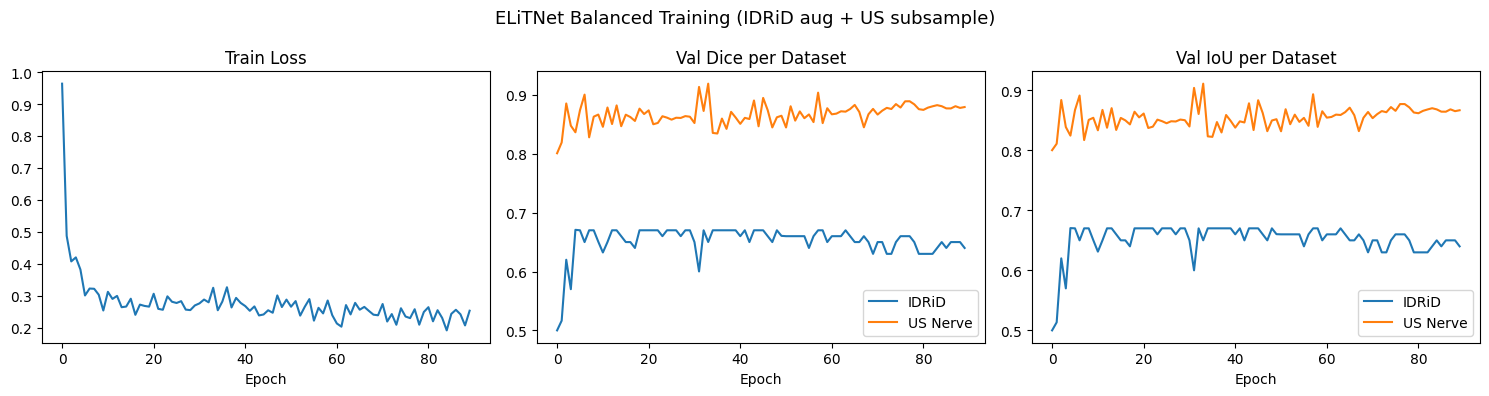

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'])
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_dice_idrid'], label='IDRiD')
axes[1].plot(history['val_dice_us'],    label='US Nerve')
axes[1].set_title('Val Dice per Dataset'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_iou_idrid'], label='IDRiD')
axes[2].plot(history['val_iou_us'],    label='US Nerve')
axes[2].set_title('Val IoU per Dataset'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle('ELiTNet Balanced Training (IDRiD aug + US subsample)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'balanced_curves.png'), dpi=120)
plt.show()